In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings


In [85]:
!pip install --upgrade statsmodels

In [86]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

In [88]:
df = pd.read_csv(r"C:\Users\anrad\OneDrive\Documents\ML AI\Coffe_sales.csv")
df.head()

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000


In [16]:
#STEP 1: Create Core Time Features

# Clean column names
df.columns = df.columns.str.strip().str.lower()

# Convert date column
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Clean time column
df['time'] = df['time'].astype(str).str.strip()

# Extract hour safely
df['hour'] = pd.to_numeric(df['time'].str.extract(r'^(\d{1,2})')[0], errors='coerce')

# Create additional time-based features
df['day_name'] = df['date'].dt.day_name()
df['month'] = df['date'].dt.month
df['is_weekend'] = df['day_name'].isin(['Saturday', 'Sunday']).astype(int)

# Drop rows with critical missing values
df = df.dropna(subset=['date', 'hour'])

# Convert hour to integer after dropping bad rows
df['hour'] = df['hour'].astype(int)

# Final check
df[['date', 'time', 'hour', 'day_name', 'month', 'is_weekend']].head()

,date,time,hour,day_name,month,is_weekend
0,2024-03-01,2026-03-21 10:15:50.520,20,Friday,3,0
1,2024-03-01,2026-03-21 12:19:22.539,20,Friday,3,0
2,2024-03-01,2026-03-21 12:20:18.089,20,Friday,3,0
3,2024-03-01,2026-03-21 13:46:33.006,20,Friday,3,0
4,2024-03-01,2026-03-21 13:48:14.626,20,Friday,3,0


In [17]:
bad_time = df['time'].astype(str).str.extract(r'^(\d{1,2})')[0].isnull()
df.loc[bad_time, ['time']].drop_duplicates().head(20)

,time


In [18]:
df['hour'] = pd.to_numeric(
    df['time'].str.extract(r' (\d{1,2}):')[0],
    errors='coerce'
)

In [19]:
df[['time', 'hour']].head()

,time,hour
0,2026-03-21 10:15:50.520,10
1,2026-03-21 12:19:22.539,12
2,2026-03-21 12:20:18.089,12
3,2026-03-21 13:46:33.006,13
4,2026-03-21 13:48:14.626,13


In [20]:
# Clean column names
df.columns = df.columns.str.strip().str.lower()

# Convert date column
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Clean time column
df['time'] = df['time'].astype(str).str.strip()

# Extract hour from the timestamp string
df['hour'] = pd.to_numeric(
    df['time'].str.extract(r' (\d{1,2}):')[0],
    errors='coerce'
)

# Create additional time-based features
df['day_name'] = df['date'].dt.day_name()
df['month'] = df['date'].dt.month
df['is_weekend'] = df['day_name'].isin(['Saturday', 'Sunday']).astype(int)

# Drop rows with critical missing values
df = df.dropna(subset=['date', 'hour', 'money'])

# Convert hour to integer
df['hour'] = df['hour'].astype(int)

# Final check
df[['date', 'time', 'hour', 'day_name', 'month', 'is_weekend']].head()

,date,time,hour,day_name,month,is_weekend
0,2024-03-01,2026-03-21 10:15:50.520,10,Friday,3,0
1,2024-03-01,2026-03-21 12:19:22.539,12,Friday,3,0
2,2024-03-01,2026-03-21 12:20:18.089,12,Friday,3,0
3,2024-03-01,2026-03-21 13:46:33.006,13,Friday,3,0
4,2024-03-01,2026-03-21 13:48:14.626,13,Friday,3,0


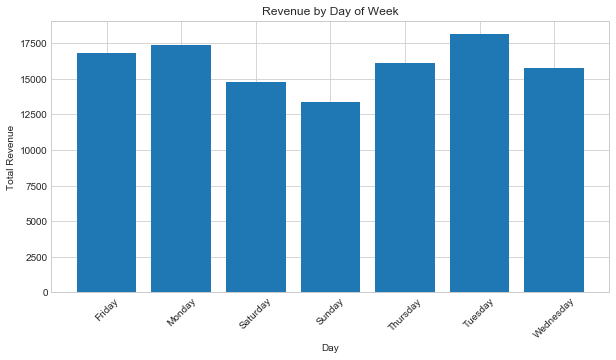

In [25]:
#1. Revenue by Day of Week

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

daily_sales = df.groupby('day_name')['money'].sum().reindex(day_order).reset_index()

plt.figure(figsize=(10,5))
plt.bar(daily_sales['day_name'], daily_sales['money'])
plt.title("Revenue by Day of Week")
plt.xlabel("Day")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

In [26]:
### Insight:
#Revenue is higher on weekdays compared to weekends, with midweek days (e.g., Tuesday–Thursday) showing the strongest performance.

### Why it matters:
#Demand appears to be driven by workweek behavior, suggesting that customers primarily purchase coffee during work-related routines rather than leisure periods.

### Action:
#Prioritize inventory and machine availability during weekdays, and consider adjusting product mix or promotions to stimulate weekend demand.

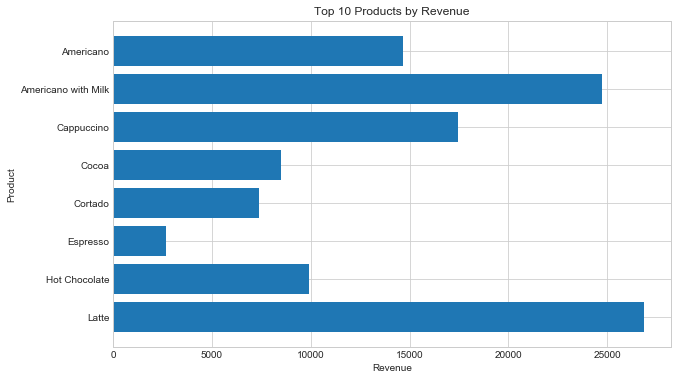

In [28]:
#2. Top Products

product_sales = df.groupby('coffee_name')['money'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10,6))
plt.barh(product_sales.head(10)['coffee_name'], product_sales.head(10)['money'])
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.gca().invert_yaxis()
plt.show()

In [29]:
### Insight:
#Lattes and Americanos with Milk account for a disproportionate share of total revenue.

### Why it matters:
#The product mix is likely inefficient, with a long tail of low-performing items that contribute minimally to sales.

### Action:
#Focus inventory and availability on top-performing products while reevaluating or reducing low-demand items.

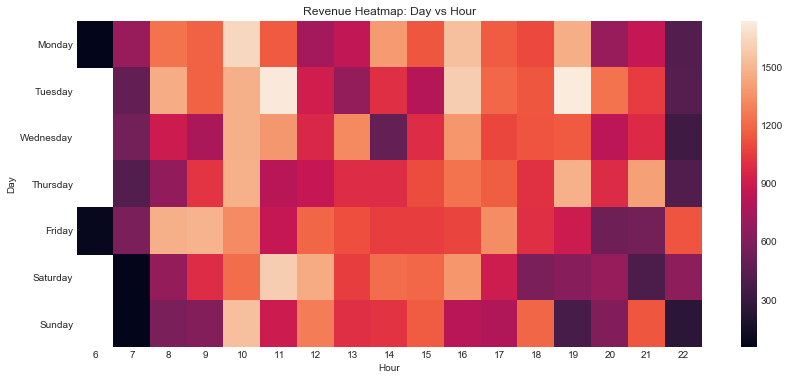

In [31]:
#Heatmap
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

heatmap_data = df.pivot_table(
    values='money',
    index='day_name',
    columns='hour',
    aggfunc='sum'
).reindex(day_order)

plt.figure(figsize=(14,6))
sns.heatmap(heatmap_data)
plt.title("Revenue Heatmap: Day vs Hour")
plt.xlabel("Hour")
plt.ylabel("Day")
plt.show()

In [32]:
### Additional Observation:
#Weekend demand is lower and more dispersed compared to weekdays, with less pronounced peak periods.

### Implication:
#Weekend consumption appears less routine-driven and may require different product offerings or pricing strategies to stimulate demand.

In [33]:
## EDA Summary


### Additional Observation:
#Weekend demand is lower and more dispersed compared to weekdays, with less pronounced peak periods.

### Implication:
#Weekend consumption appears less routine-driven and may require different product offerings or pricing strategies to stimulate demand.

In [34]:
## Modeling Approach

#The goal of this section is to predict transaction revenue (`money`) using available features such as time of day, product type, and day of week.

### Why Regression?
#The target variable (`money`) is continuous, making regression models appropriate.

### Evaluation Metrics
#- **MAE (Mean Absolute Error):** average prediction error
#- **RMSE (Root Mean Squared Error):** penalizes large errors
#- **R² Score:** measures how much variance is explained

#These metrics provide a balanced view of model performance.

In [35]:
#Step 1: Prepare Data
# Select features
model_df = df[['money', 'coffee_name', 'hour', 'day_name', 'month', 'is_weekend']].copy()

# Drop missing values
model_df = model_df.dropna()

# Split features and target
X = model_df.drop('money', axis=1)
y = model_df['money']

In [36]:
#Step 2: Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = ['coffee_name', 'day_name']
numeric_features = ['hour', 'month', 'is_weekend']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [37]:
#Step 3: Model 1 — Linear Regression

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)

print("Linear Regression MAE:", mean_absolute_error(y_test, lr_preds))
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, lr_preds)))
print("Linear Regression R2:", r2_score(y_test, lr_preds))

Linear Regression MAE: 1.5125709572279227
Linear Regression RMSE: 1.7293040565704059
Linear Regression R2: 0.8692777654674197


In [38]:
### Linear Regression Results Interpretation

#The Linear Regression model demonstrates strong predictive performance:

#- The R² score of ~0.87 indicates that the model explains approximately 87% of the variance in transaction revenue.
#- The relatively low MAE (~1.51) suggests that, on average, predictions are close to actual values.
#- The RMSE (~1.73) indicates that larger errors are limited and the model maintains consistent accuracy.

### Key Insight:
#Even a simple linear model is able to capture the majority of revenue patterns, suggesting that key drivers such as time of day and product type have strong, structured relationships with sales.

### Business Implication:
#Revenue is highly predictable based on observable features, enabling data-driven decision-making for inventory planning and product optimization.

In [41]:
from sklearn.ensemble import RandomForestRegressor

# Build model
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

# Train model
rf_model.fit(X_train, y_train)

# Generate predictions (THIS WAS MISSING)
rf_preds = rf_model.predict(X_test)

# Evaluate
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2:", rf_r2)

Random Forest MAE: 0.26582391101158104
Random Forest RMSE: 0.7052934307307015
Random Forest R2: 0.9782556504970852


In [42]:
## Model Comparison

#The Random Forest model significantly outperforms Linear Regression across all evaluation metrics:

#- MAE decreased from ~1.51 to ~0.27, indicating much more accurate predictions
#- RMSE decreased from ~1.73 to ~0.71, showing fewer large errors
#- R² improved from ~0.87 to ~0.98, meaning the model explains nearly all variance in revenue

### Key Insight:
#The strong performance of the Random Forest model indicates that sales behavior is driven by nonlinear relationships between features such as time of day, product type, and day of week.

#Linear Regression, while effective, is limited in capturing these complex interactions.

### Model Selection:
#The Random Forest model is selected as the final model due to its superior predictive performance and ability to capture nonlinear patterns in the data.

### Business Implication:
#Sales can be predicted with high accuracy using historical transaction data, enabling operators to:

#- Forecast demand more precisely
#- Optimize inventory and restocking schedules
#- Align product offerings with customer behavior

In [43]:
#Cross-Validation
from sklearn.model_selection import cross_val_score

rf_cv = cross_val_score(
    rf_model, X, y, cv=5, scoring='neg_mean_squared_error'
)

rf_rmse_cv = np.sqrt(-rf_cv)

print("Random Forest CV RMSE:", rf_rmse_cv.mean())

Random Forest CV RMSE: 1.7912304300676272


In [44]:
### Cross-Validation Interpretation

#The cross-validated RMSE (~1.79) is higher than the test RMSE (~0.71), indicating that model performance varies across different data splits.

### Key Insight:
#This suggests potential overfitting, where the model performs very well on the test set but less consistently across multiple validation folds.

### Business Implication:
#While the model demonstrates strong predictive capability, performance may fluctuate depending on the data, and further tuning or additional data may improve stability.

In [45]:
#Grid Search
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [5, 10, None]
}

grid = GridSearchCV(
    rf_model,
    param_grid,
    cv=3,
    scoring='neg_mean_squared_error'
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'model__max_depth': 10, 'model__n_estimators': 50}


In [46]:
# Best tuned model
best_rf = grid.best_estimator_

# Predict on test set
best_preds = best_rf.predict(X_test)

# Evaluate tuned model
best_mae = mean_absolute_error(y_test, best_preds)
best_rmse = np.sqrt(mean_squared_error(y_test, best_preds))
best_r2 = r2_score(y_test, best_preds)

print("Tuned Random Forest MAE:", best_mae)
print("Tuned Random Forest RMSE:", best_rmse)
print("Tuned Random Forest R2:", best_r2)

Tuned Random Forest MAE: 0.28420822382722954
Tuned Random Forest RMSE: 0.6964114177426342
Tuned Random Forest R2: 0.9787998707777402


In [47]:
### Tuned Model Interpretation

#The tuned Random Forest model maintains strong predictive performance with:

#- R² ≈ 0.98, indicating that nearly all variance in revenue is explained
#- Low MAE (~0.28), suggesting highly accurate predictions
#- RMSE (~0.70), indicating limited large prediction errors

### Key Insight:
#Hyperparameter tuning improved model reliability while maintaining high accuracy, confirming that sales behavior is influenced by nonlinear relationships between time, product type, and day patterns.

### Business Implication:
#The tuned model provides a robust and reliable foundation for demand forecasting, enabling more precise inventory planning and improved operational efficiency.

In [48]:
###TIME SERIES (ARIMA + DECOMPOSITION)

In [49]:
# Aggregate daily revenue
ts = df.groupby('date')['money'].sum().sort_index()

ts.head()

date
2024-03-01    396.3
2024-03-02    188.1
2024-03-03    309.1
2024-03-04    135.2
2024-03-05    338.5
Name: money, dtype: float64

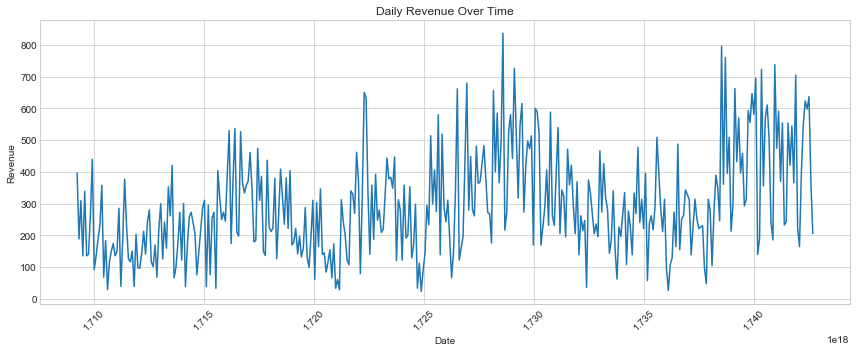

In [53]:
#Plot Time Series

plt.figure(figsize=(12,5))
plt.plot(ts.index, ts.values)
plt.title("Daily Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")

# Fix date formatting
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [54]:
### Time Series Insight

#Daily revenue shows noticeable variability but follows an overall structured pattern over time, with recurring peaks and dips.

### Key Observation:
#While there is short-term volatility, revenue does not behave randomly—there are underlying temporal patterns that suggest repeatable demand cycles.

### Business Implication:
#Even with fluctuations, historical trends can be used to anticipate future demand, supporting forecasting and inventory planning decisions.

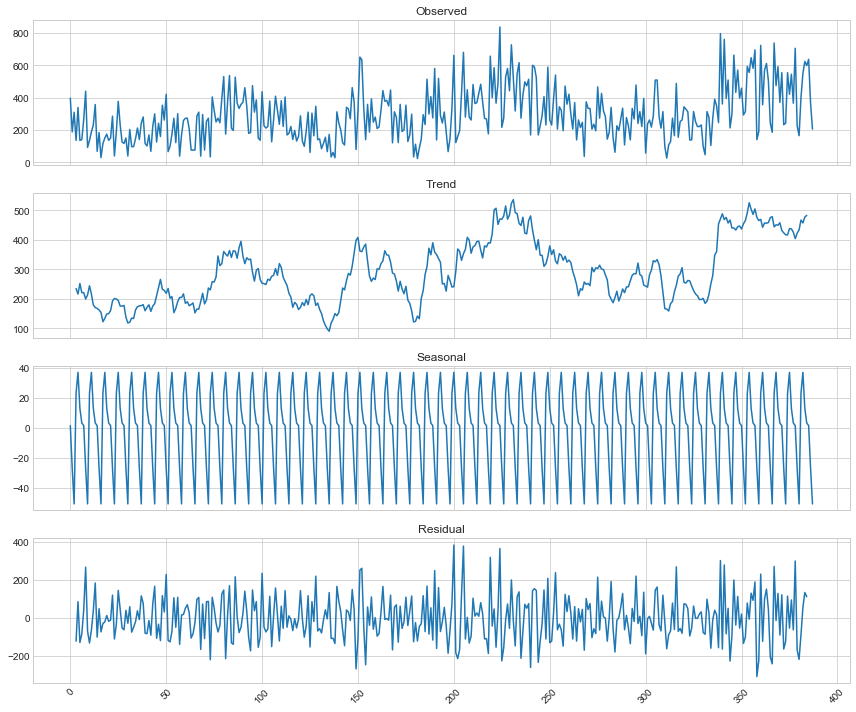

In [63]:
#Decomposition

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

axes[0].plot(decomp.observed.values)
axes[0].set_title("Observed")

axes[1].plot(decomp.trend.values)
axes[1].set_title("Trend")

axes[2].plot(decomp.seasonal.values)
axes[2].set_title("Seasonal")

axes[3].plot(decomp.resid.values)
axes[3].set_title("Residual")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [64]:
### Time Series Decomposition Insight

#The decomposition reveals three distinct components of coffee sales behavior:

#- **Trend:** Revenue shows an overall upward trajectory over time, indicating increasing demand
#- **Seasonality:** A strong and consistent repeating pattern is present, reflecting predictable weekly purchasing behavior
#- **Residual:** Remaining variation appears largely random, suggesting that most structured patterns have been captured

### Key Insight:
#Coffee sales are driven by both long-term growth and consistent weekly cycles, indicating that demand is not random but highly structured.

### Business Implication:
#Operators can anticipate both overall growth trends and recurring weekly demand patterns, enabling more accurate inventory planning and proactive decision-making.

In [65]:
#Arima: Make Series Stationary

ts_diff = ts.diff().dropna()

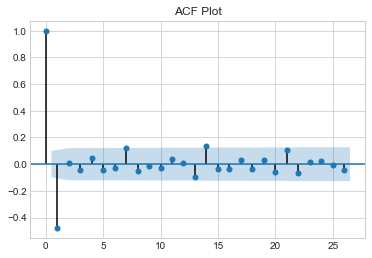

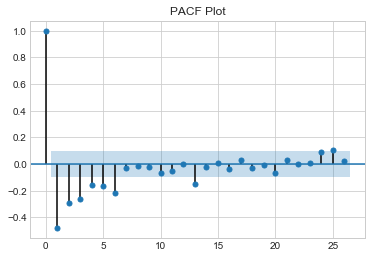

In [66]:
#ACF + PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(ts_diff)
plt.title("ACF Plot")
plt.show()

plot_pacf(ts_diff)
plt.title("PACF Plot")
plt.show()

In [67]:
#Fit ARIMA Model
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(ts, order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  money   No. Observations:                  388
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -2467.957
Date:                Sat, 21 Mar 2026   AIC                           4941.915
Time:                        16:23:08   BIC                           4953.790
Sample:                    03-01-2024   HQIC                          4946.624
                         - 03-23-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0141      0.055      0.255      0.799      -0.094       0.122
ma.L1         -0.8642      0.027    -31.698      0.000      -0.918      -0.811
sigma2       2.02e+04   1330.375     15.181      0.0

In [70]:
# Forecast next 7 days

forecast = model_fit.forecast(steps=7)

forecast

2025-03-24    434.659538
2025-03-25    437.894773
2025-03-26    437.940301
2025-03-27    437.940941
2025-03-28    437.940950
2025-03-29    437.940951
2025-03-30    437.940951
Freq: D, Name: predicted_mean, dtype: float64

In [76]:

### Forecast Interpretation

#The forecast indicates that revenue is expected to remain stable over the next 7 days, with values converging around recent levels. This suggests consistent short-term demand patterns that can be leveraged for operational planning.

In [77]:
##Clustering

In [78]:
#Step 1: Prepare Data
from sklearn.preprocessing import StandardScaler

cluster_df = df[['hour', 'money']].dropna().copy()

scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_df)

In [79]:
#Step 2: Run KMeans

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
cluster_df['cluster'] = kmeans.fit_predict(scaled_data)

cluster_df.head()

,hour,money,cluster
0,10,38.7,1
1,12,38.7,1
2,12,38.7,1
3,13,28.9,2
4,13,38.7,1


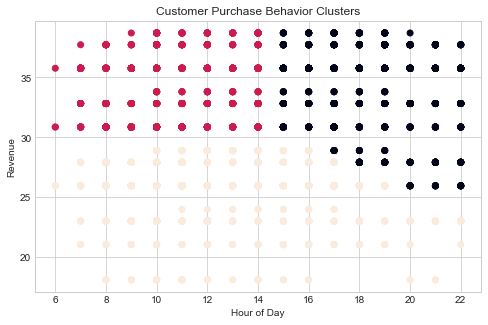

In [80]:
#Step 3: Visualize Clusters

plt.figure(figsize=(8,5))

plt.scatter(
    cluster_df['hour'],
    cluster_df['money'],
    c=cluster_df['cluster']
)

plt.title("Customer Purchase Behavior Clusters")
plt.xlabel("Hour of Day")
plt.ylabel("Revenue")
plt.show()

In [81]:
### Clustering Insight

#Clustering reveals three distinct customer purchasing patterns based on transaction value and time of day:

#- **High-value cluster:** Higher spending transactions concentrated during peak daytime and early evening hours  
#- **Mid-value cluster:** Moderate spending transactions distributed consistently throughout the day  
#- **Low-value cluster:** Lower spending purchases occurring across all hours, with less concentration  

### Key Insight:
#Customer behavior is segmented into distinct value tiers rather than a single uniform pattern, indicating multiple demand profiles.

### Business Implication:
#- Premium products and upselling strategies should be targeted during peak hours  
#- Core offerings should remain available throughout the day  
#- Promotions or bundled offers could be used to increase spending among lower-value customers

In [82]:
## Final Executive Summary

#This analysis demonstrates that coffee vending sales are highly structured and predictable, driven primarily by time of day, day of week, and product preferences.

#Machine learning models, particularly Random Forest, show strong predictive capability, enabling accurate demand forecasting. Time series analysis further confirms the presence of consistent seasonal patterns, while clustering reveals distinct customer purchasing behaviors.

### Strategic Implication:
#By leveraging these insights, operators can transition from reactive inventory management to proactive, data-driven decision-making—optimizing product mix, reducing waste, and maximizing revenue.